In [1]:
import pandas as pd
import numpy as np

from statsmodels.formula.api import ols

from statsmodels.graphics.api import plot_corr # визуализация корреляционной матрицы
from statsmodels.iolib.summary2 import summary_params # вывод результатов тестирования
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF # VIF

from scipy.stats import f # f-распределение и критические значения
from scipy.stats import t # f-распределение и критические значения

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warning
import warnings
warnings.simplefilter(action='ignore', category=Warning)

Matplotlib is building the font cache; this may take a moment.


# 1

In [2]:
# загрузим данные
df = pd.read_csv('sleep75.csv')

In [3]:
# спецификация модели через формулу
mod = ols(formula='sleep~1+I(totwrk / 100)+I(totwrk**2 / 100)+age+smsa+male', data=df)
# подгонка модели с неробастной оценкой ковариационной матрицы
res = mod.fit()

In [4]:
# проверим значимость коэффициентов используя P-value
summary_params(res).round(4)

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,3428.8048,76.6550,44.7303,0.0000,3278.3035,3579.3062
I(totwrk / 100),-8.1953,4.7894,-1.7111,0.0875,-17.5987,1.2081
I(totwrk ** 2 / 100),-0.0021,0.0011,-1.9302,0.0540,-0.0043,0.0000
age,2.8167,1.3869,2.0309,0.0426,0.0937,5.5397
smsa,-78.0495,32.0724,-2.4335,0.0152,-141.0190,-15.0799
male,86.6388,34.2000,2.5333,0.0115,19.4920,153.7855


In [5]:
# Матрица регрессионного дизайна X (первый столбе состои только из единиц)
# mod.exog
# Для наглядности представим в виде pandsa DataFrame
X = pd.DataFrame(mod.exog, columns=mod.exog_names)
X

,Intercept,I(totwrk / 100),I(totwrk ** 2 / 100),age,smsa,male
0,1.0,34.38,118198.44,32.0,0.0,1.0
1,1.0,50.20,252004.00,31.0,0.0,1.0
2,1.0,28.15,79242.25,44.0,1.0,1.0
3,1.0,37.86,143337.96,30.0,0.0,0.0
4,1.0,25.80,66564.00,64.0,0.0,1.0
...,...,...,...,...,...,...
701,1.0,20.26,41046.76,45.0,1.0,0.0
702,1.0,6.75,4556.25,34.0,0.0,1.0
703,1.0,18.51,34262.01,37.0,0.0,0.0
704,1.0,19.61,38455.21,54.0,0.0,0.0


In [6]:
# Корреляционная матрицы для регрессоров
# Отметим, что нужно исключить первый столбец из единиц
corr_matrix = X.drop(columns='Intercept').corr()
corr_matrix.round(3)

,I(totwrk / 100),I(totwrk ** 2 / 100),age,smsa,male
I(totwrk / 100),1.000,0.937,-0.050,-0.038,0.376
I(totwrk ** 2 / 100),0.937,1.000,-0.046,-0.051,0.351
age,-0.050,-0.046,1.000,0.025,0.032
smsa,-0.038,-0.051,0.025,1.000,0.007
male,0.376,0.351,0.032,0.007,1.000


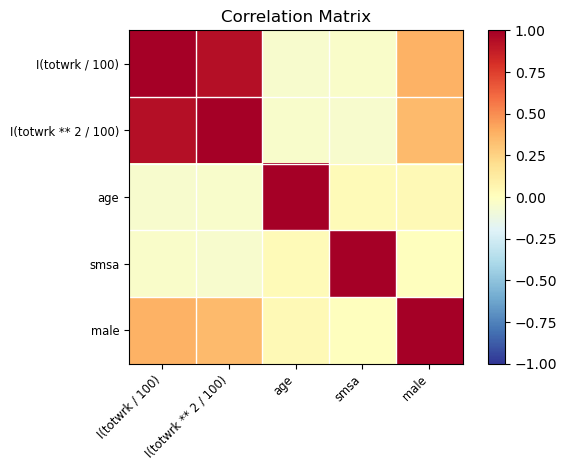

In [7]:
# Визуализация корреляций
plot_corr(corr_matrix, xnames=mod.exog_names[1:], normcolor=True)
plt.show()

In [8]:
# уровень значимости
sign_level = 0.05
# критическое значение t-распределения
t.ppf(q=1-sign_level/2, df=mod.df_resid)

np.float64(1.963358711099814)

age, smsa, male значимы потому что у них |t значение| > t критич

In [15]:
F_test = res.f_test('I(totwrk / 100) = I(totwrk ** 2 / 100)=0')
print(F_test)

<F test: F=45.61921736022586, p=2.3808537039297265e-19, df_denom=700, df_num=2>


In [17]:
# уровень значимости
sign_level = 0.05
# Критическое значение F-распределения
f.isf(q=sign_level, dfn=F_test.df_num, dfd=F_test.df_denom)

np.float64(3.0085895184656937)

Гипотеза отвергается, т.к. F статистика > F критического значения

### VIF

In [18]:
# имена экзогенных переменных
mod.exog_names

['Intercept', 'I(totwrk / 100)', 'I(totwrk ** 2 / 100)', 'age', 'smsa', 'male']

In [21]:
# Напечатаем все VIF
for i in np.arange(1, len(mod.exog_names)):
    print(f'VIF({mod.exog_names[i]})={round(VIF(exog=X, exog_idx=i),3)}')

VIF(I(totwrk / 100))=8.37
VIF(I(totwrk ** 2 / 100))=8.199
VIF(age)=1.006
VIF(smsa)=1.004
VIF(male)=1.169


# 2

In [22]:
# спецификация модели через формулу
mod = ols(formula='sleep~1+totwrk+age+I(age**2)+smsa+male+union', data=df)
# подгонка модели с неробастной оценкой ковариационной матрицы
res = mod.fit()

In [23]:
# проверим значимость коэффициентов используя P-value
summary_params(res).round(4)

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,3688.5513,218.3893,16.8898,0.0000,3259.7737,4117.3290
totwrk,-0.1653,0.0181,-9.1053,0.0000,-0.2009,-0.1296
age,-7.7337,11.2128,-0.6897,0.4906,-29.7485,14.2811
I(age ** 2),0.1271,0.1340,0.9482,0.3434,-0.1361,0.3902
smsa,-74.5269,32.1563,-2.3176,0.0208,-137.6614,-11.3924
male,86.3215,34.3287,2.5146,0.0121,18.9217,153.7212
union,8.5744,38.1947,0.2245,0.8224,-66.4156,83.5645


In [24]:
# Матрица регрессионного дизайна X (первый столбе состои только из единиц)
# mod.exog
# Для наглядности представим в виде pandsa DataFrame
X = pd.DataFrame(mod.exog, columns=mod.exog_names)
X

,Intercept,totwrk,age,I(age ** 2),smsa,male,union
0,1.0,3438.0,32.0,1024.0,0.0,1.0,0.0
1,1.0,5020.0,31.0,961.0,0.0,1.0,0.0
2,1.0,2815.0,44.0,1936.0,1.0,1.0,0.0
3,1.0,3786.0,30.0,900.0,0.0,0.0,0.0
4,1.0,2580.0,64.0,4096.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
701,1.0,2026.0,45.0,2025.0,1.0,0.0,0.0
702,1.0,675.0,34.0,1156.0,0.0,1.0,1.0
703,1.0,1851.0,37.0,1369.0,0.0,0.0,0.0
704,1.0,1961.0,54.0,2916.0,0.0,0.0,1.0


In [25]:
# Корреляционная матрицы для регрессоров
# Отметим, что нужно исключить первый столбец из единиц
corr_matrix = X.drop(columns='Intercept').corr()
corr_matrix.round(3)

,totwrk,age,I(age ** 2),smsa,male,union
totwrk,1.000,-0.050,-0.067,-0.038,0.376,0.002
age,-0.050,1.000,0.992,0.025,0.032,-0.037
I(age ** 2),-0.067,0.992,1.000,0.024,0.026,-0.042
smsa,-0.038,0.025,0.024,1.000,0.007,-0.039
male,0.376,0.032,0.026,0.007,1.000,0.040
union,0.002,-0.037,-0.042,-0.039,0.040,1.000


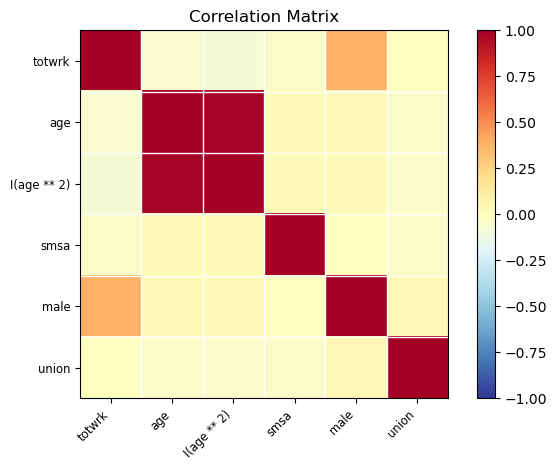

In [26]:
# Визуализация корреляций
plot_corr(corr_matrix, xnames=mod.exog_names[1:], normcolor=True)
plt.show()

In [27]:
# имена экзогенных переменных
mod.exog_names

['Intercept', 'totwrk', 'age', 'I(age ** 2)', 'smsa', 'male', 'union']

In [28]:
# Напечатаем все VIF
for i in np.arange(1, len(mod.exog_names)):
    print(f'VIF({mod.exog_names[i]})={round(VIF(exog=X, exog_idx=i),3)}')

VIF(totwrk)=1.195
VIF(age)=65.397
VIF(I(age ** 2))=65.561
VIF(smsa)=1.004
VIF(male)=1.172
VIF(union)=1.007


In [30]:
# уровень значимости
sign_level = 0.05
# критическое значение t-распределения
t.ppf(q=1-sign_level/2, df=mod.df_resid)

np.float64(1.963363575920925)

totwrk, smsa, male значимы т.к. их |t значения| > t крита

In [31]:
F_test = res.f_test('age = I(age ** 2)=0')
print(F_test)

<F test: F=2.496529538578492, p=0.08310459895158286, df_denom=699, df_num=2>


In [32]:
# уровень значимости
sign_level = 0.05
# Критическое значение F-распределения
f.isf(q=sign_level, dfn=F_test.df_num, dfd=F_test.df_denom)

np.float64(3.0086079648642867)

Гипотеза не отвергается, т.к. F статистика < F cr

# 3

In [34]:
# спецификация модели через формулу
mod = ols(formula='sleep~1+totwrk+age+smsa+south+I(totwrk*south)+I(age*south)+I(smsa*south)', data=df)
# подгонка модели с неробастной оценкой ковариационной матрицы
res = mod.fit()

In [35]:
# Матрица регрессионного дизайна X (первый столбе состои только из единиц)
# mod.exog
# Для наглядности представим в виде pandsa DataFrame
X = pd.DataFrame(mod.exog, columns=mod.exog_names)
X

,Intercept,totwrk,age,smsa,south,I(totwrk * south),I(age * south),I(smsa * south)
0,1.0,3438.0,32.0,0.0,0.0,0.0,0.0,0.0
1,1.0,5020.0,31.0,0.0,1.0,5020.0,31.0,0.0
2,1.0,2815.0,44.0,1.0,0.0,0.0,0.0,0.0
3,1.0,3786.0,30.0,0.0,0.0,0.0,0.0,0.0
4,1.0,2580.0,64.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
701,1.0,2026.0,45.0,1.0,0.0,0.0,0.0,0.0
702,1.0,675.0,34.0,0.0,0.0,0.0,0.0,0.0
703,1.0,1851.0,37.0,0.0,0.0,0.0,0.0,0.0
704,1.0,1961.0,54.0,0.0,1.0,1961.0,54.0,0.0


In [36]:
# Корреляционная матрицы для регрессоров
# Отметим, что нужно исключить первый столбец из единиц
corr_matrix = X.drop(columns='Intercept').corr()
corr_matrix.round(3)

,totwrk,age,smsa,south,I(totwrk * south),I(age * south),I(smsa * south)
totwrk,1.000,-0.050,-0.038,0.051,0.175,0.033,0.012
age,-0.050,1.000,0.025,-0.018,-0.038,0.126,0.008
smsa,-0.038,0.025,1.000,-0.238,-0.224,-0.222,0.209
south,0.051,-0.018,-0.238,1.000,0.932,0.947,0.359
I(totwrk * south),0.175,-0.038,-0.224,0.932,1.000,0.868,0.328
I(age * south),0.033,0.126,-0.222,0.947,0.868,1.000,0.351
I(smsa * south),0.012,0.008,0.209,0.359,0.328,0.351,1.000


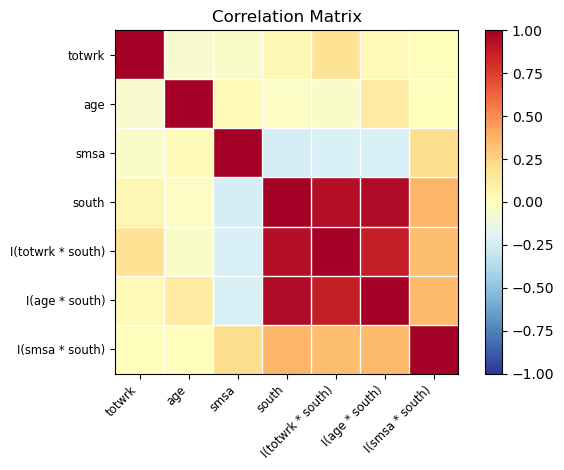

In [37]:
# Визуализация корреляций
plot_corr(corr_matrix, xnames=mod.exog_names[1:], normcolor=True)
plt.show()

In [38]:
# имена экзогенных переменных
mod.exog_names

['Intercept',
 'totwrk',
 'age',
 'smsa',
 'south',
 'I(totwrk * south)',
 'I(age * south)',
 'I(smsa * south)']

In [40]:
# Напечатаем все VIF
for i in np.arange(1, len(mod.exog_names)):
    print(f'VIF({mod.exog_names[i]})={round(VIF(exog=X, exog_idx=i),3)}')

VIF(totwrk)=1.148
VIF(age)=1.249
VIF(smsa)=1.187
VIF(south)=22.002
VIF(I(totwrk * south))=8.852
VIF(I(age * south))=12.277
VIF(I(smsa * south))=1.286


In [41]:
# проверим значимость коэффициентов используя P-value
summary_params(res).round(4)


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,3557.5131,75.5044,47.1166,0.0000,3409.2701,3705.7561
totwrk,-0.1607,0.0177,-9.0617,0.0000,-0.1955,-0.1259
age,1.4852,1.5451,0.9612,0.3368,-1.5485,4.5189
smsa,-61.5538,34.8564,-1.7659,0.0778,-129.9898,6.8822
south,-407.2056,189.6269,-2.1474,0.0321,-779.5132,-34.8981
I(totwrk * south),0.0785,0.0504,1.5562,0.1201,-0.0205,0.1774
I(age * south),8.2666,3.4949,2.3653,0.0183,1.4048,15.1283
I(smsa * south),49.4288,107.1110,0.4615,0.6446,-160.8696,259.7272


In [42]:
# уровень значимости
sign_level = 0.05
# критическое значение t-распределения
t.ppf(q=1-sign_level/2, df=mod.df_resid)

np.float64(1.9633684547051231)

totwrk, south, I(age * south) значимы, т.к. их |t статистика| > t крита

In [43]:
F_test = res.f_test('south = I(totwrk * south) = I(age * south) = I(smsa * south) =0')
print(F_test)

<F test: F=3.144161493313561, p=0.014101731941962176, df_denom=698, df_num=4>


In [44]:
# уровень значимости
sign_level = 0.05
# Критическое значение F-распределения
f.isf(q=sign_level, dfn=F_test.df_num, dfd=F_test.df_denom)

np.float64(2.384692685857469)

Гипотеза отвергается т.к. F стата 2.38 < F крита 3.14